# Week 6 - Bivariate Analysis, part 2

# 1. Lesson: no lesson this week

# 2. Weekly graph question

Suppose you wanted to show the nitrate and phosphate level in a water sample.  What are the advantages and disadvantages of showing this as an area plot, as opposed to two separate line graphs?  How would you adjust the graphs shown to improve the presentation?

In [49]:
import numpy as np
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

/tmp/ipykernel_174/2149468501.py:4: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  datearray = pd.date_range(start='2023/01/01', end='2024/01/01', freq='M')


Text(0, 0.5, 'Nitrate level (% of eutrophic value)')

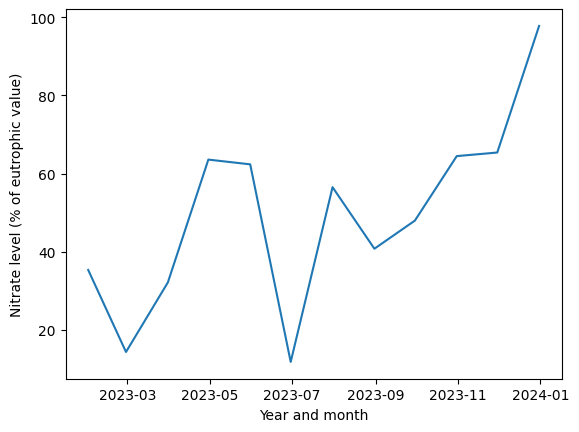

In [50]:
numdates = 12
np.random.seed(0)
time_series = 100 * (np.random.normal(size = numdates) / 5 + np.arange(numdates) / 16)
datearray = pd.date_range(start='2023/01/01', end='2024/01/01', freq='M')
ax = sns.lineplot(x = datearray, y = time_series)
ax.set_xlabel("Year and month")
ax.set_ylabel("Nitrate level (% of eutrophic value)")

/tmp/ipykernel_174/1726504607.py:3: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  datearray = pd.date_range(start='2023/01/01', end='2024/01/01', freq='M')


Text(0, 0.5, 'Phosphate level (% of eutrophic value)')

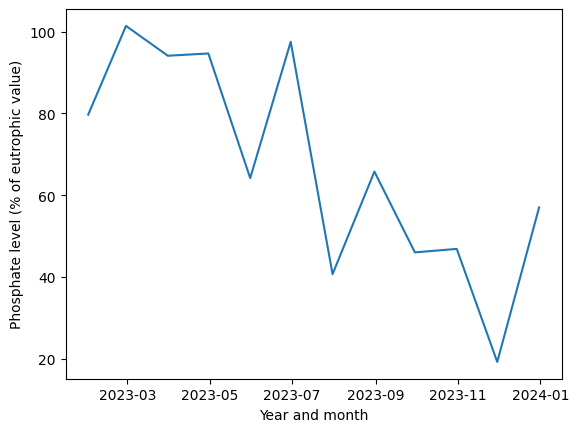

In [51]:
np.random.seed(1)
time_series_2 =  100 * (1 - (np.random.normal(size = numdates) / 8 + np.arange(numdates) / 16))
datearray = pd.date_range(start='2023/01/01', end='2024/01/01', freq='M')
ax = sns.lineplot(x = datearray, y = time_series_2)
ax.set_xlabel("Year and month")
ax.set_ylabel("Phosphate level (% of eutrophic value)")

<Axes: >

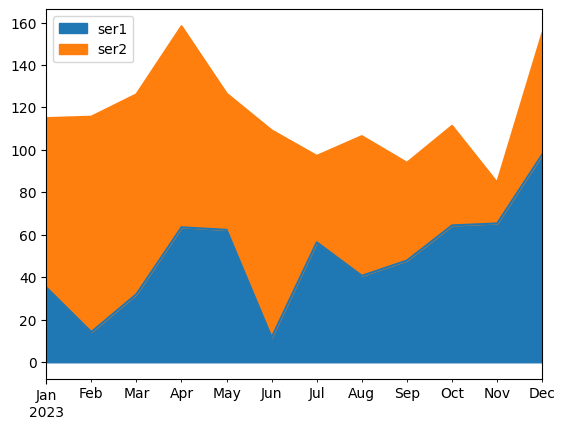

In [52]:
df = pd.DataFrame({'ser1': time_series, 'ser2': time_series_2}, index = datearray)
df.plot.area()

**Advantages of an area plot:**

An area plot makes it easy to see the combined magnitude and overall trend of nitrate and phosphate levels over time. It visually emphasizes how the two variables contribute to the total level and makes patterns or changes across months easy to spot.

**Disadvantages:**

Area plots can sometimes hide individual trends, especially if the areas overlap or stack. It can also make it harder to accurately compare the exact values of nitrate and phosphate because the stacked shading can be misleading.

**Advantages of two separate line graphs:**

Two line graphs make it easier to compare the precise trends and values of each nutrient individually. They provide a clearer view of increases or decreases without visual interference from the other variable.

**Improving the presentation:**

*   Add clear titles and legends identifying nitrate and phosphate.

*   Use distinct colors for each variable.


*   Rotate or format the date labels for readability.

*   Add grid lines and consistent axis scales.
*  If using an area plot, transparency (alpha) would be considered so overlapping areas remain visible.






# 3. Working on your datasets

This week, you will do the same types of exercises as last week, but you should use your chosen datasets that someone in your class found last semester. (They likely will not be the particular datasets that you found yourself.)

### Here are some types of analysis you can do:

- Find correlations between pairs of variables.

- Draw scatterplots, especially when the correlation is large.

- Draw pairplots.

- Draw line graphs and/or area graphs when there is date or time data together with numerical data.

### Conclusions:

- Explain what conclusions you would draw from this analysis: are the data what you expect?  Are the data likely to be usable?  If the data are not useable, find some new data!

- Do you see any outliers?  (Data points that are far from the rest of the data).

- Are any data items highly correlated with each other, suggesting that they are redundant?

- For the line plots, do you see a trend or pattern over time?  Does this suggest that the data are changing over time (drifting) in such a way as to invalidate comparisons?

- Can you think of any confounding variables?  (Third variables that could explain any correlations between other variables.  These third variables may or may not be reported in the dataset.)

In [53]:
# Load the Dataset

df_medical = pd.read_csv("medical_insurance.csv")


In [54]:
# Summarize the Dataset using info() and describe()

# Dataset structure
df_medical.info()

# Statistical summary of numerical columns
df_medical.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 54 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   person_id                    100000 non-null  int64  
 1   age                          100000 non-null  int64  
 2   sex                          100000 non-null  object 
 3   region                       100000 non-null  object 
 4   urban_rural                  100000 non-null  object 
 5   income                       100000 non-null  float64
 6   education                    100000 non-null  object 
 7   marital_status               100000 non-null  object 
 8   employment_status            100000 non-null  object 
 9   household_size               100000 non-null  int64  
 10  dependents                   100000 non-null  int64  
 11  bmi                          100000 non-null  float64
 12  smoker                       100000 non-null  object 
 13  

,person_id,age,income,household_size,dependents,bmi,visits_last_year,hospitalizations_last_3yrs,days_hospitalized_last_3yrs,medication_count,...,liver_disease,arthritis,mental_health,proc_imaging_count,proc_surgery_count,proc_physio_count,proc_consult_count,proc_lab_count,is_high_risk,had_major_procedure
count,100000.000000,100000.000000,1.000000e+05,100000.000000,100000.000000,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,...,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000
mean,50000.500000,47.521500,4.987390e+04,2.430900,0.898380,26.990512,1.92765,0.093640,0.373350,1.236320,...,0.014770,0.108310,0.130140,0.508530,0.158690,0.508390,0.50933,0.509140,0.367810,0.169700
std,28867.657797,15.988752,4.680021e+04,1.075126,0.950654,4.994883,1.73773,0.304848,1.373011,1.209358,...,0.120632,0.310773,0.336459,0.749755,0.463562,0.747218,0.75363,0.750455,0.482212,0.375371
min,1.000000,0.000000,1.100000e+03,1.000000,0.000000,12.000000,0.00000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000
25%,25000.750000,37.000000,2.110000e+04,2.000000,0.000000,23.600000,1.00000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000
50%,50000.500000,48.000000,3.620000e+04,2.000000,1.000000,27.000000,2.00000,0.000000,0.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000
75%,75000.250000,58.000000,6.220000e+04,3.000000,1.000000,30.400000,3.00000,0.000000,0.000000,2.000000,...,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,1.00000,1.000000,1.000000,0.000000
max,100000.000000,100.000000,1.061800e+06,9.000000,7.000000,50.400000,25.00000,3.000000,21.000000,11.000000,...,1.000000,1.000000,1.000000,7.000000,6.000000,7.000000,7.00000,7.000000,1.000000,1.000000


In [55]:
# Number of duplicate rows
df_medical.duplicated().sum()

# Display duplicate rows if any
df_medical[df_medical.duplicated()]


,person_id,age,sex,region,urban_rural,income,education,marital_status,employment_status,household_size,...,liver_disease,arthritis,mental_health,proc_imaging_count,proc_surgery_count,proc_physio_count,proc_consult_count,proc_lab_count,is_high_risk,had_major_procedure


In [56]:
# Count duplicates in each column
for col in df_medical.columns:
    duplicates = df_medical[col].duplicated().sum()
    print(col, ":", duplicates)


person_id : 0
age : 99899
sex : 99997
region : 99995
urban_rural : 99997
income : 97013
education : 99994
marital_status : 99996
employment_status : 99996
household_size : 99991
dependents : 99992
bmi : 99660
smoker : 99997
alcohol_freq : 99996
visits_last_year : 99978
hospitalizations_last_3yrs : 99996
days_hospitalized_last_3yrs : 99984
medication_count : 99988
systolic_bp : 99881
diastolic_bp : 99928
ldl : 98119
hba1c : 99268
plan_type : 99996
network_tier : 99996
deductible : 99996
copay : 99996
policy_term_years : 99990
policy_changes_last_2yrs : 99997
provider_quality : 99650
risk_score : 99908
annual_medical_cost : 8701
annual_premium : 44462
monthly_premium : 87661
claims_count : 99978
avg_claim_amount : 46929
total_claims_paid : 43350
chronic_count : 99993
hypertension : 99998
diabetes : 99998
asthma : 99998
copd : 99998
cardiovascular_disease : 99998
cancer_history : 99998
kidney_disease : 99998
liver_disease : 99998
arthritis : 99998
mental_health : 99998
proc_imaging_count 

In [57]:
# Mean (numerical columns)
df_medical.mean(numeric_only=True)

# Median (numerical columns)
df_medical.median(numeric_only=True)

# Mode (works for both numeric and categorical)
df_medical.mode()


,person_id,age,sex,region,urban_rural,income,education,marital_status,employment_status,household_size,...,liver_disease,arthritis,mental_health,proc_imaging_count,proc_surgery_count,proc_physio_count,proc_consult_count,proc_lab_count,is_high_risk,had_major_procedure
0,1,50.0,Female,South,Urban,21300.0,Bachelors,Married,Employed,2.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,99996,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
99996,99997,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
99997,99998,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
99998,99999,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [58]:
# Count missing values per column
df_medical.isnull().sum()


,0
person_id,0
age,0
sex,0
region,0
urban_rural,0
income,0
education,0
marital_status,0
employment_status,0
household_size,0


In [59]:
# Fill missing numerical values with column mean
df_medical.fillna(df_medical.mean(numeric_only=True), inplace=True)


In [60]:
df_medical.info()
df_medical.describe()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 54 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   person_id                    100000 non-null  int64  
 1   age                          100000 non-null  int64  
 2   sex                          100000 non-null  object 
 3   region                       100000 non-null  object 
 4   urban_rural                  100000 non-null  object 
 5   income                       100000 non-null  float64
 6   education                    100000 non-null  object 
 7   marital_status               100000 non-null  object 
 8   employment_status            100000 non-null  object 
 9   household_size               100000 non-null  int64  
 10  dependents                   100000 non-null  int64  
 11  bmi                          100000 non-null  float64
 12  smoker                       100000 non-null  object 
 13  

,person_id,age,income,household_size,dependents,bmi,visits_last_year,hospitalizations_last_3yrs,days_hospitalized_last_3yrs,medication_count,...,liver_disease,arthritis,mental_health,proc_imaging_count,proc_surgery_count,proc_physio_count,proc_consult_count,proc_lab_count,is_high_risk,had_major_procedure
count,100000.000000,100000.000000,1.000000e+05,100000.000000,100000.000000,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,...,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000
mean,50000.500000,47.521500,4.987390e+04,2.430900,0.898380,26.990512,1.92765,0.093640,0.373350,1.236320,...,0.014770,0.108310,0.130140,0.508530,0.158690,0.508390,0.50933,0.509140,0.367810,0.169700
std,28867.657797,15.988752,4.680021e+04,1.075126,0.950654,4.994883,1.73773,0.304848,1.373011,1.209358,...,0.120632,0.310773,0.336459,0.749755,0.463562,0.747218,0.75363,0.750455,0.482212,0.375371
min,1.000000,0.000000,1.100000e+03,1.000000,0.000000,12.000000,0.00000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000
25%,25000.750000,37.000000,2.110000e+04,2.000000,0.000000,23.600000,1.00000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000
50%,50000.500000,48.000000,3.620000e+04,2.000000,1.000000,27.000000,2.00000,0.000000,0.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000
75%,75000.250000,58.000000,6.220000e+04,3.000000,1.000000,30.400000,3.00000,0.000000,0.000000,2.000000,...,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,1.00000,1.000000,1.000000,0.000000
max,100000.000000,100.000000,1.061800e+06,9.000000,7.000000,50.400000,25.00000,3.000000,21.000000,11.000000,...,1.000000,1.000000,1.000000,7.000000,6.000000,7.000000,7.00000,7.000000,1.000000,1.000000


In [61]:
# Find Correlations Between Variables

# Select numerical variables only
corr_matrix = df_medical.corr(numeric_only=True)

print(corr_matrix)


                             person_id       age    income  household_size  \
person_id                     1.000000  0.000160  0.002109       -0.004329   
age                           0.000160  1.000000  0.005382        0.000895   
income                        0.002109  0.005382  1.000000       -0.004950   
household_size               -0.004329  0.000895 -0.004950        1.000000   
dependents                   -0.004821 -0.000482 -0.002082        0.885795   
bmi                          -0.000179  0.001980 -0.002565       -0.006505   
visits_last_year              0.004654  0.062841  0.000578        0.000148   
hospitalizations_last_3yrs   -0.002365  0.005274 -0.004660       -0.002195   
days_hospitalized_last_3yrs  -0.003638  0.005812 -0.001539       -0.000722   
medication_count             -0.000202  0.055155  0.003684       -0.001023   
systolic_bp                   0.001459  0.555174  0.002011        0.002732   
diastolic_bp                 -0.000736  0.304183  0.003527      

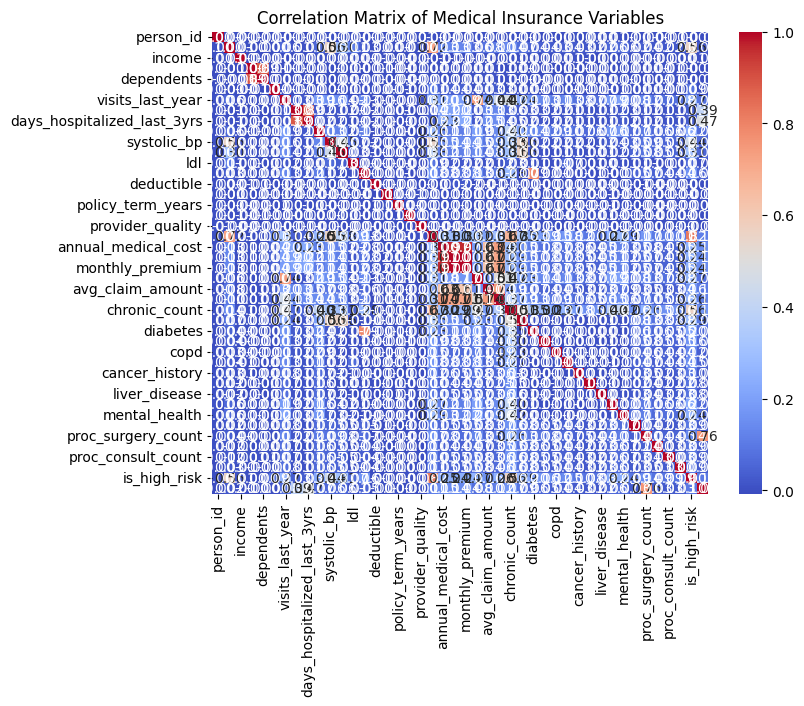

In [62]:
# Correlation Heatmap

import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix of Medical Insurance Variables")
plt.show()


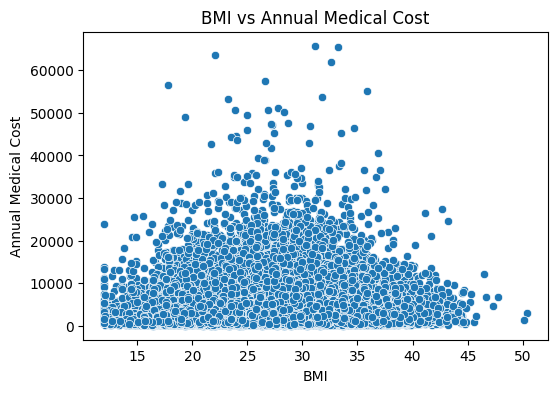

In [63]:
# Draw Scatterplots

# BMI vs Annual Medical Cost

plt.figure(figsize=(6,4))

sns.scatterplot(data=df_medical, x="bmi", y="annual_medical_cost")

plt.title("BMI vs Annual Medical Cost")
plt.xlabel("BMI")
plt.ylabel("Annual Medical Cost")

plt.show()



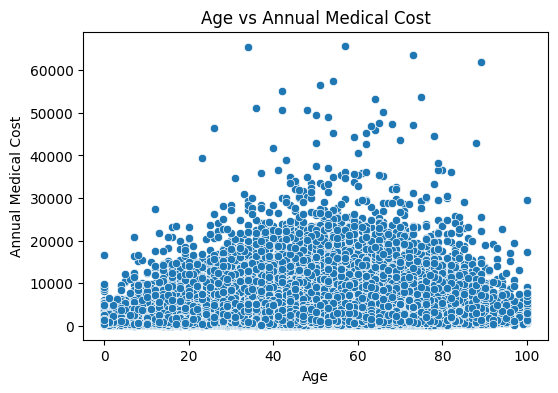

In [64]:
# Age vs Annual Medical Cost

plt.figure(figsize=(6,4))

sns.scatterplot(data=df_medical, x="age", y="annual_medical_cost")

plt.title("Age vs Annual Medical Cost")
plt.xlabel("Age")
plt.ylabel("Annual Medical Cost")

plt.show()


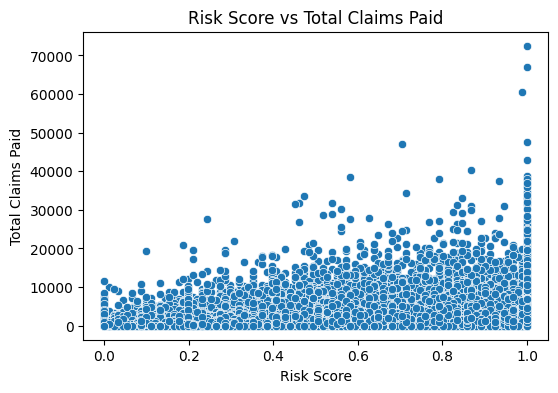

In [65]:
# Risk Score vs Total Claims Paid

plt.figure(figsize=(6,4))

sns.scatterplot(data=df_medical, x="risk_score", y="total_claims_paid")

plt.title("Risk Score vs Total Claims Paid")
plt.xlabel("Risk Score")
plt.ylabel("Total Claims Paid")

plt.show()


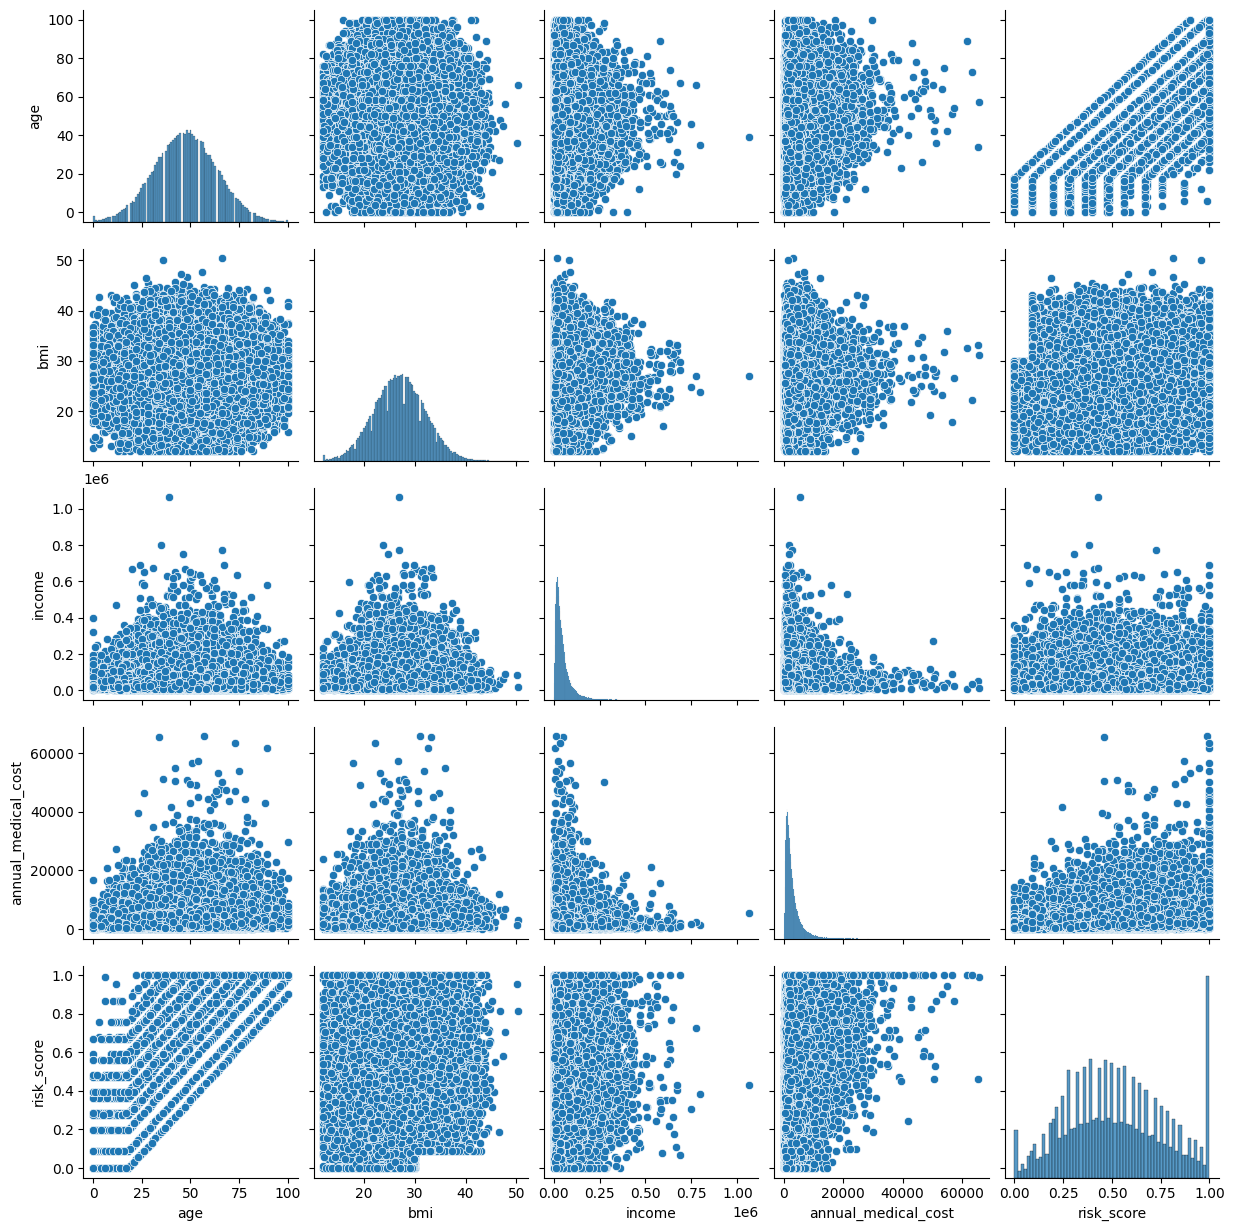

In [66]:
# Pair Plot Of Key Variables

subset = df_medical[[
    "age",
    "bmi",
    "income",
    "annual_medical_cost",
    "risk_score"
]]

sns.pairplot(subset)
plt.show()




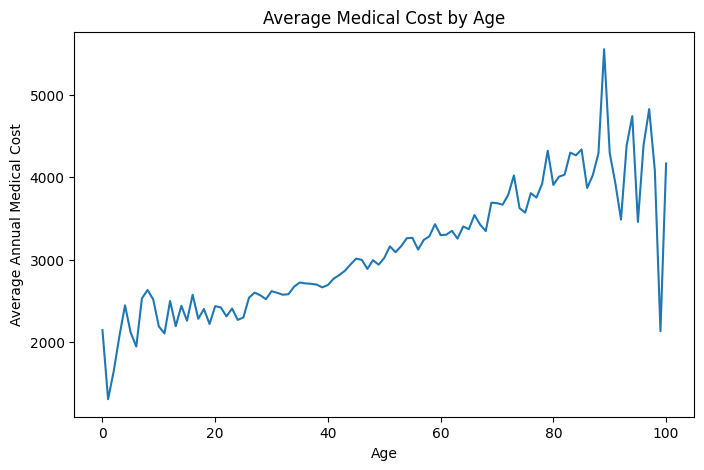

In [67]:
# Example Line Graph (Grouped Trends)

age_cost = df_medical.groupby("age")["annual_medical_cost"].mean()

plt.figure(figsize=(8,5))
age_cost.plot()
plt.title("Average Medical Cost by Age")
plt.xlabel("Age")
plt.ylabel("Average Annual Medical Cost")
plt.show()


**Conclusions**

The dataset contains 100,000 records and 54 variables, including demographic information, health indicators, insurance details, and medical utilization metrics. The data appear well structured and mostly complete, with only minor missing values in the alcohol frequency variable.

Correlation analysis suggests relationships between risk score, claims counts, and annual medical costs, which is expected because individuals with higher health risk typically require more medical services. Scatterplots also suggest that age and BMI may influence medical costs, although the relationships appear somewhat scattered.

Some variables appear highly related or potentially redundant, such as claims count, average claim amount, and total claims paid, since these variables measure similar aspects of healthcare spending.

Several outliers are visible, particularly in variables like income, annual medical cost, and number of medical visits, where a small number of individuals have extremely high values. These likely represent individuals with significant medical needs rather than errors in the dataset.

The dataset does not contain true time-series data, so long-term trends cannot be directly analyzed. However, examining average cost by age suggests that healthcare expenses tend to increase with age.

Possible confounding variables include smoking status, chronic disease indicators, BMI, and risk score. These variables could explain relationships between demographic factors and medical costs.

Overall, the dataset appears usable for exploratory analysis and predictive modeling, particularly for studying healthcare costs and risk factors.

# 4. Storytelling With Data plot

Reproduce any graph of your choice in p. 86-98 of the Storytelling With Data book as best you can.  (The second half of chapter three).  You do not have to get the exact data values right, just the overall look and feel.

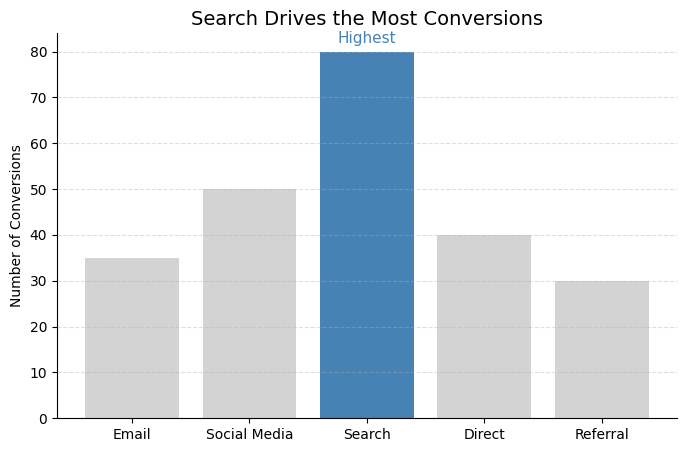

In [68]:


# Example data
categories = ["Email", "Social Media", "Search", "Direct", "Referral"]
values = [35, 50, 80, 40, 30]

df_story = pd.DataFrame({
    "Channel": categories,
    "Conversions": values
})

# Highlight one bar
colors = ["lightgray", "lightgray", "steelblue", "lightgray", "lightgray"]

# Create figure and axis
fig, ax = plt.subplots(figsize=(8,5))

ax.bar(df_story["Channel"], df_story["Conversions"], color=colors)

ax.set_title("Search Drives the Most Conversions", fontsize=14)
ax.set_ylabel("Number of Conversions")

# Remove unnecessary chart elements
ax.grid(axis="y", linestyle="--", alpha=0.4)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Annotation
ax.text(2, 82, "Highest", ha="center", fontsize=11, color="steelblue")

plt.show()